                                PPROJECT TITLE 
        Strategic Profitability Analysis of Promotional Campaigns in Retail Pharmacy
                     Case Study: Nahdi Pharmacy (Feb – Apr 2026)

Excetive  Summary:

This project delivers a strategic and data-driven evaluation of promotional campaigns executed at Nahdi Pharmacy over a three-month period. While promotions are traditionally deployed to stimulate sales volume and customer acquisition, their true impact on profitability, margin sustainability, and incremental growth remains uncertain.

This analysis moves beyond surface-level sales uplift to assess whether promotions:

1.Generate incremental revenue or merely shift demand forward

2.Drive profitable growth or dilute margins through excessive discounting

3.Attract high-value customers or incentivize price-sensitive behavior

By integrating pricing, discount depth, and product-level performance, this study identifies hidden margin leakage and uncovers opportunities to optimize promotional efficiency.

Problem Statement:

Nahdi Pharmacy operates in a highly competitive, price-sensitive environment, where promotions are a key lever to:

Increase store traffic
Expand basket size
Defend market share against competitors

However, without robust optimization, promotions can create a false sense of growth—increasing revenue while silently eroding profitability.

The core challenge is:

Are promotions creating real economic value, or simply trading margin for volume

Project Objectives

1. Promotion Strategy Diagnostics

-Identifing dominant promotion types (e.g., % discount, bundle, BOGO)

-Evaluating distribution across categories and brands

-Detecting of  over-reliance on margin-eroding tactics

2. Discount Depth vs Revenue Quality Analysis

-Analyze relationship between discount % (Depth) and:

-Sales uplift

-Margin dilution

-Identify the optimal discount threshold beyond which profitability declines

3.Evaluation of Promotion Effectiveness by Product Category

4.Gain Made by Customers vs Loss to Company

Quantify:

    -Customer savings (discount captured)

    -Company revenue sacrificed

    -Estimate net value transfer:

Who benefits more — the customer or the business?

5.Incrementality Assessment 

    Distinguishing  between:

-Incremental sales (new demand)

-Cannibalized sales (would have occurred anyway)

Flag promotions that:

Shift timing instead of creating value

Reduce full-price purchasing behavior


Data Constraints Acknowledgment 

Due to the absence of cost and customer-level data, the analysis focuses on proxy indicators of profitability, including:

Discount depth (%)

Price vs promo price variance

Category and brand performance

Offer type effectiveness


Key Metrics Developed

Average Discount % by Offer Type

Revenue Lift per Promotion

Estimated Margin Erosion Index

Customer Savings Ratio

Promotion Efficiency Score (Revenue Generated / Discount Given)



In [351]:
import pandas as pd
import numpy as np

import glob
import os

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBRegressor


import shap
shap.initjs()

In [352]:
def load_files(folder_path):

    df_list = []

    for file in os.listdir(folder_path):

        file_path = os.path.join(r"C:\Users\PAVILION PLUS\Desktop\nahdi data for analysis", file)

        try:

            if file.endswith(".csv"):
                df = pd.read_csv(file_path)

            elif file.endswith(".xlsx"):
                df = pd.read_excel(file_path)
            elif file.endswith('.js'):
                df=pd.read_json(file_path)
            elif file.endswith('.txt'):
                df=pd.read_table(file_path)

            else:
                continue

            df['source_file'] = file
            df_list.append(df)

            print(f"{file} loaded successfully")

        except Exception as e:
            print(f"Error loading {file}: {e}")

    return pd.concat(df_list, ignore_index=True)






# #faster version
# def load_excel_files(folder_path):

#     files = glob.glob(folder_path + "/*.xlsx")

#     df = pd.concat(
#         [pd.read_excel(file).assign(source_file=file.split("\\")[-1]) for file in files],
#         ignore_index=True
#     )

#     return df



# #production excel loader

# def load_promo_files(folder_path):

#     files = glob.glob(os.path.join(folder_path, "*.xlsx"))
#     df_list = []

#     for file in files:

#         try:

#             sheets = pd.read_excel(file, sheet_name=None)

#             for sheet_name, df in sheets.items():

#                 if df.empty:
#                     continue

#                 # Clean column names
#                 df.columns = (
#                     df.columns
#                     .str.strip()
#                     .str.lower()
#                     .str.replace(" ", "_")
#                 )

#                 # Track file + sheet
#                 df["source_file"] = os.path.basename(file)
#                 df["sheet_name"] = sheet_name

#                 df_list.append(df)

#             print(f"Loaded: {os.path.basename(file)}")

#         except Exception as e:

#             print(f"Error loading {file}: {e}")

#     combined_df = pd.concat(df_list, ignore_index=True, sort=False)

#     print(f"\nTotal rows loaded: {len(combined_df)}")

#     return combined_df

In [353]:
df = load_files(r"C:\Users\PAVILION PLUS\Desktop\nahdi data for analysis")
df

APRIL.xlsx loaded successfully
FEBRUARY.xlsx loaded successfully
MARCH.xlsx loaded successfully


,Division,Department,Category,Item Brand,Period,Channel,Group_Code,ITEM,English Description,OFFER TYPE,Price with VAT,Promo Price with VAT,Saving,Depth%,START_DATE,END_DATE,source_file
0,BEAUTY,COSMETIC,FRAGRANCES,Christian Dior,Full,BM & Online,FChor20,103184367,Christian Dior miss dior EDP100 ml,Direct_Discount,712.17,569.75,142.0,0.199997,2026-04-01,2026-04-30,APRIL.xlsx
1,BEAUTY,COSMETIC,FRAGRANCES,Christian Dior,Full,BM & Online,FChor20,103183866,Christian Dior sauvage Perfume 200 ml,Direct_Discount,1054.57,843.70,210.0,0.200000,2026-04-01,2026-04-30,APRIL.xlsx
2,BEAUTY,COSMETIC,FRAGRANCES,Christian Dior,Full,BM & Online,FChor20,103183807,Christian Dior pure poison EDP100 ml,Direct_Discount,712.17,569.75,142.0,0.199997,2026-04-01,2026-04-30,APRIL.xlsx
3,BEAUTY,COSMETIC,FRAGRANCES,Christian Dior,Full,BM & Online,FChor20,103181908,Christian Dior dior homme intense EDP150 ml,Direct_Discount,725.86,580.70,145.0,0.200000,2026-04-01,2026-04-30,APRIL.xlsx
4,BEAUTY,COSMETIC,FRAGRANCES,Christian Dior,Full,BM & Online,FChor20,103183129,Christian Dior hypnotic poison EDP100 ml,Direct_Discount,712.17,569.75,142.0,0.199997,2026-04-01,2026-04-30,APRIL.xlsx
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20952,WELLNESS,NUTRACEUTICALS AND NUTRITION,GENERAL HEALTH,Beatswell,Full,BM only,1_227650,102234692,Beatswell Vitamin C + Zinc 20 Effervescent Tab...,BUY 1 GET 1 FREE,50.00,25.05,24.0,NaN,2026-03-01,2026-03-31,MARCH.xlsx
20953,WELLNESS,NUTRACEUTICALS AND NUTRITION,WOMEN HEALTH,Beatswell,Full,BM only,1_227650,102209657,Beatswell Iron + Vitamin C 20 Effervescent Tab...,BUY 1 GET 1 FREE,58.11,29.10,29.0,NaN,2026-03-01,2026-03-31,MARCH.xlsx
20954,WELLNESS,NUTRACEUTICALS AND NUTRITION,GENERAL HEALTH,Beatswell,Full,BM only,1_227650,102525668,Beatswell Multivitamin Energy 20 Effervescent ...,BUY 1 GET 1 FREE,60.00,30.00,30.0,NaN,2026-03-01,2026-03-31,MARCH.xlsx
20955,WELLNESS,NUTRACEUTICALS AND NUTRITION,WOMEN HEALTH,Beatswell,Full,BM only,1_227650,102499615,Beatswell Calcium + Mg + D3 15 Effervescent Ta...,BUY 1 GET 1 FREE,49.80,24.90,24.0,NaN,2026-03-01,2026-03-31,MARCH.xlsx


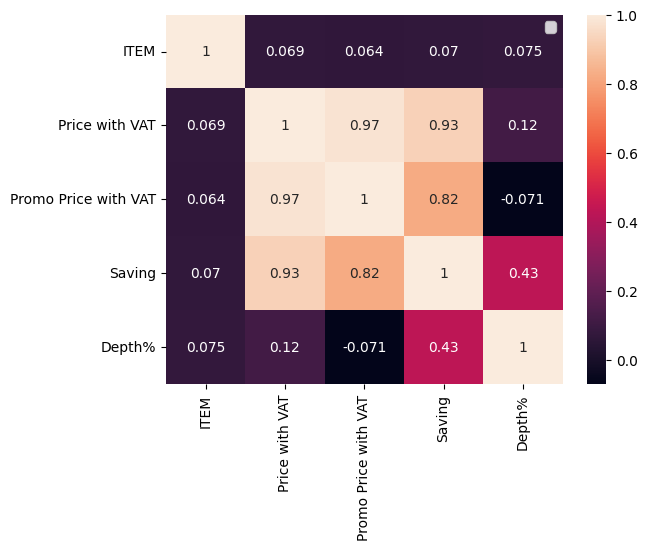

In [354]:
data_corr=df.corr(numeric_only=True)
sns.heatmap(data_corr,annot=True)
plt.legend('numerical correction')
plt.show()

In [355]:
df['START_DATE'] = pd.to_datetime(df['START_DATE'], errors='coerce')
df['END_DATE'] = pd.to_datetime(df['END_DATE'], errors='coerce')

FEATURE ENGINEERING

In [356]:
#Promotion Duration
df['Promo_Duration'] = (df['END_DATE'] - df['START_DATE']).dt.days

#Discount Percentage
df['Calculated_Discount'] = (df['Price with VAT'] - df['Promo Price with VAT']) / df['Price with VAT']*100

#Price Reduction
df['Price_Reduction'] = df['Price with VAT'] - df['Promo Price with VAT']

#Discount Depth
df['Discount_Depth'] = df['Saving'] / df['Price with VAT'] 

#Price Category
df['Price_Category'] = pd.qcut(df['Price with VAT'], q=4, labels=['Low','Medium','High','Premium'])

#calculated distance category
df['Calculated_Discount_catrgory']  = pd.qcut(df['Calculated_Discount'], q=3, labels=['Low','High','Premium'])

#Promotion Month
df['Promo_Month'] = df['START_DATE'].dt.month

#"corrected_Depth%"
mapping = {
    'BUY 2 GET 1 FREE ': 1,
    'BUY 1 GET 1 FREE ': 1,
    'BUY 2 GET 2 FREE ':2,
    'BUY 1 GET 1 WITH PERCENT OFF 30':.30, 
    'BUY 1 GET 1 WITH PERCENT OFF 40':.40,
    'BUY 1 GET 1 WITH PERCENT OFF 50':.50,
    'BUY 1 GET 1 WITH PERCENT OFF 60':.60,
    'BUY 1 GET 1 WITH PERCENT OFF 70':.70,
    'BUY 1 GET 2 FREE ':2,
    '(B/G) BUY 2 GET 1 FREE ':1,
    'BUY 1 GET 1 WITH PERCENT OFF 70': .30

}
df["corrected_Depth%"] = df.apply( lambda row: mapping[row["OFFER TYPE"]] if row["OFFER TYPE"] in mapping else row["Depth%"], axis=1)

#LABELS
mapping = {
    'Accez':'PL',
    'Active Go':'PL',
    'Alfoshan':'PL',
    'ALmisan':'PL', 
    'AURI':'PL',
    'Babygee':'PL',
    'Babywell':'PL',
    'Beatswell':'PL',
    'Bibi':'PL',
    'Bio-Synergy':'PL',
    'Blade':'PL',
    'Body Spa':'PL',
    'BODYLICIOUS':'PL',
    'Boutique':'PL',
    'Citizen':'PL',
    'Clary':'PL',
    'Clevie':'PL',
    'Clevie Derma':'PL',
    'Connect':'PL',
    'COXIR':'PL',
    'Creigtons':'PL',
    'Davids':'PL',
    'Emotion':'PL',
    'Eric Favre':'PL',
    'Febella':'PL',
    'First Aids Kit':'PL',
    'Footness':'PL',
    'Fragrances For Her':'PL',
    'Fruit Works':'PL',
    'Gamar':'PL',
    'Grit':'PL',
    'I Kuzma':'PL',
    'Kaiyang':'PL',
    'Keller':'PL',
    'Killys':'PL',
    'Mades':'PL',
    'Martini':'PL',
    'Medex':'PL',
    'Molfix':'PL',
    'Movera':'PL',
    'Movera Ortho':'PL',
    'Movera Sport':'PL',
    'MUVU':'PL',
    'Nahdi':'PL',
    'NUTSHELL':'PL',
    'OE':'PL',
    'OnCall':'PL',
    'Orex':'PL',
    'Parsa':'PL',
    'Parsa Beauty':'PL',
    'Qure':'PL',
    'Rosal':'PL',
    'Sanotact':'PL',
    'Shadez':'PL',
    'True Honey':'PL',
    'Velveta':'PL',
    'Viora':'PL',
    'Yunmai':'PL',
    'Yuwell':'PL',
    'ZAK':'PL'

}
df["LABELS"] = df.apply( lambda row: mapping[row["Item Brand"]] if row["Item Brand"] in mapping else 'OTHERS', axis=1)


DETAILING OF OBJECTIVES

# OBJECTIVE 1.Promotion Strategy Diagnostics

OFFER TYPE
Direct_Discount                    26.998139
BUY 2 GET 1 FREE                   23.495729
BUY 1 GET 1 FREE                   16.481367
BUY 1 GET 1 WITH PERCENT OFF 50    10.841246
BUY 2 GET 2 FREE                    9.634013
BUY 1 GET 1 WITH PERCENT OFF 40     8.751253
BUY 1 GET 1 WITH PERCENT OFF 30     2.648280
BUY 1 GET 1 WITH PERCENT OFF 60     0.763468
BUY 1 GET 2 FREE                    0.257670
(B/G) BUY 2 GET 1 FREE              0.081118
BUY 1 GET 1 WITH PERCENT OFF 70     0.047717
Name: proportion, dtype: float64


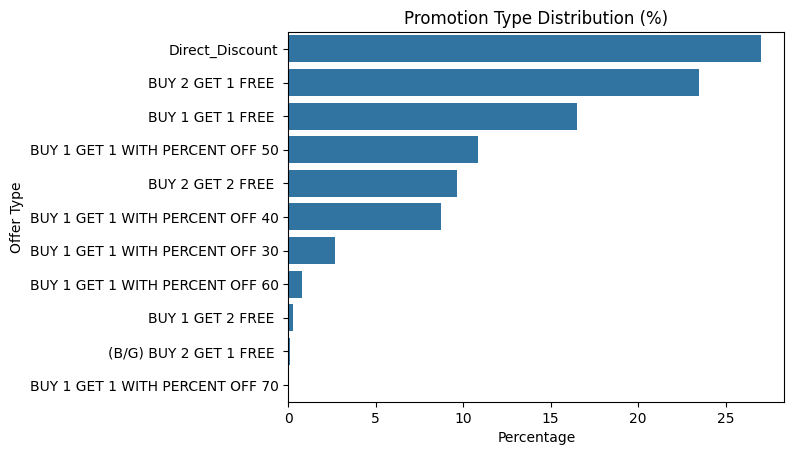

In [357]:
#1.1 Dominant Promotion Types
promo_dist = df['OFFER TYPE'].value_counts(normalize=True) * 100

print(promo_dist)

sns.barplot(x=promo_dist.values, y=promo_dist.index)
plt.title("Promotion Type Distribution (%)")
plt.xlabel("Percentage")
plt.ylabel("Offer Type")
plt.show()

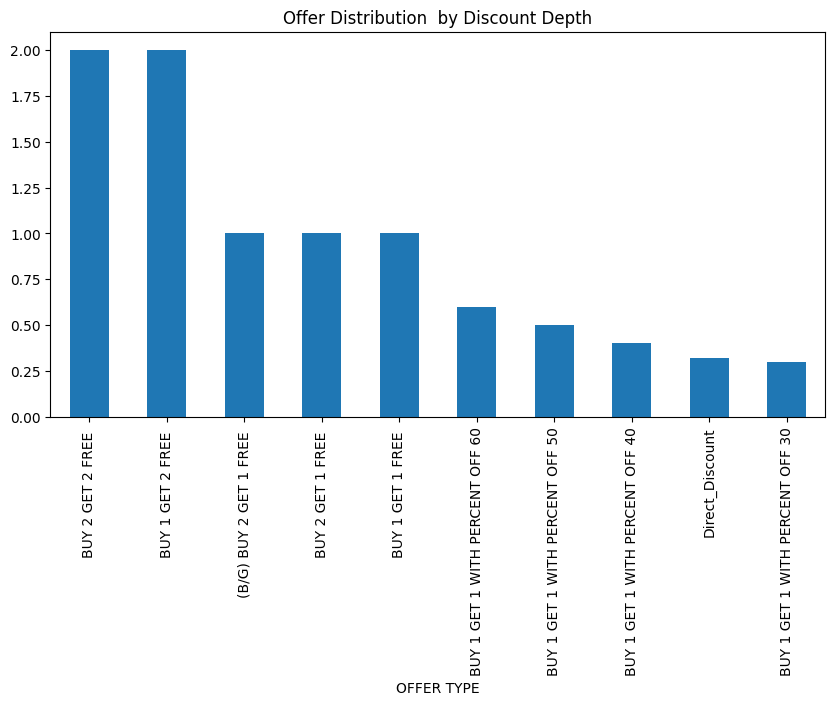

In [358]:
#1.2
offer_distribution = (
    df.groupby('OFFER TYPE')['corrected_Depth%']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

offer_distribution.plot(kind='bar', figsize=(10,5), title='Offer Distribution  by Discount Depth')
plt.show()

In [359]:
#1.3
promo_dist_month = df.groupby('Promo_Month')['OFFER TYPE'].value_counts(normalize=True) * 100
promo_dist_month

Promo_Month  OFFER TYPE                     
2            BUY 2 GET 1 FREE                   27.146320
             BUY 2 GET 2 FREE                   24.837352
             Direct_Discount                    20.653145
             BUY 1 GET 1 FREE                   19.874984
             BUY 1 GET 1 WITH PERCENT OFF 50     5.931879
             BUY 1 GET 1 WITH PERCENT OFF 30     0.650593
             BUY 1 GET 1 WITH PERCENT OFF 60     0.331675
             BUY 1 GET 2 FREE                    0.306162
             (B/G) BUY 2 GET 1 FREE              0.140324
             BUY 1 GET 1 WITH PERCENT OFF 70     0.127567
3            Direct_Discount                    30.292490
             BUY 1 GET 1 WITH PERCENT OFF 40    25.849802
             BUY 1 GET 1 WITH PERCENT OFF 50    18.134387
             BUY 2 GET 1 FREE                   16.079051
             BUY 1 GET 1 FREE                    8.537549
             BUY 1 GET 2 FREE                    0.474308
             BUY 1 GET 1 WI

In [360]:
#1.4
promo_dist_month_labels = df.groupby(['LABELS','Promo_Month'])['OFFER TYPE'].value_counts(normalize=True) * 100
promo_dist_month_labels

LABELS  Promo_Month  OFFER TYPE                     
OTHERS  2            BUY 2 GET 1 FREE                   31.775422
                     BUY 2 GET 2 FREE                   29.072719
                     Direct_Discount                    18.605346
                     BUY 1 GET 1 FREE                   12.154696
                     BUY 1 GET 1 WITH PERCENT OFF 50     6.809019
                     BUY 1 GET 1 WITH PERCENT OFF 30     0.761535
                     BUY 1 GET 1 WITH PERCENT OFF 60     0.388234
                     BUY 1 GET 2 FREE                    0.358369
                     (B/G) BUY 2 GET 1 FREE              0.074660
        3            BUY 1 GET 1 WITH PERCENT OFF 40    31.273910
                     Direct_Discount                    29.648049
                     BUY 2 GET 1 FREE                   19.452946
                     BUY 1 GET 1 FREE                    9.429992
                     BUY 1 GET 1 WITH PERCENT OFF 50     8.856159
                     BU

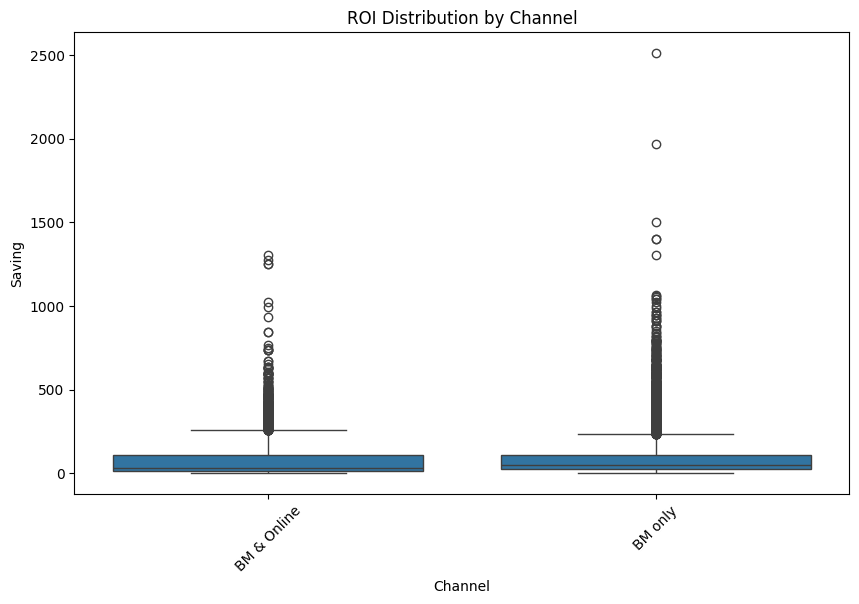

In [361]:
#1.5
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Channel', y='Saving')
plt.title("ROI Distribution by Channel")
plt.xticks(rotation=45)
plt.show()

In [362]:
#1.6 Distribution Across Categories & Brands

category_promo = pd.crosstab(df['Category'], df['OFFER TYPE'], normalize='index') * 100
brand_promo = pd.crosstab(df['Item Brand'], df['OFFER TYPE'], normalize='index') * 100



In [363]:
#1.7 Over-Reliance on Margin-Eroding Promotions

high_discount_threshold = df['corrected_Depth%'].quantile(0.75)

high_discount_ratio = (
    df[df['corrected_Depth%'] > high_discount_threshold]
    .groupby('Category')
    .size() / df.groupby('Category').size()
).fillna(0)

print(high_discount_ratio.sort_values(ascending=False))

Category
NAILS                      0.506438
MAKEUP                     0.321303
BEAUTY SKIN CARE           0.243051
HAIR TREATMENT             0.171990
DERMO SKIN CARE            0.127444
HAIR COLOR                 0.097087
HAIR REMOVALS              0.056818
PAIN MANAGEMENT            0.052632
MEN GROOMING               0.051282
HAND HYGIENE               0.034483
BABY TOILETRIES            0.025370
INTIMATE HYGIENE           0.020833
WOMEN HEALTH               0.015801
DEODORANTS                 0.013889
GENERAL HEALTH             0.009597
REGULAR SKIN CARE          0.004762
DAILY HAIR CARE            0.003546
BODY MOISTURIZERS          0.003300
BEAUTY ACCESSORIES         0.002411
CLEAN HAIR CARE            0.000000
BREATH FRESHENER           0.000000
BODY SUPPORT               0.000000
BODY FRESHENERS            0.000000
BABY WIPES                 0.000000
BATH AND SHOWER            0.000000
ADVANCED ORAL CARE         0.000000
BABY MILK                  0.000000
BABY FOOD          

# OBJECTIVE 2.Discount Depth vs Revenue Quality Analysis

In [364]:
#2.1 Create Discount Buckets

bins = [0, 10, 20, 30, 40, 50, 100]
labels = ['0-10%', '10-20%', '20-30%', '30-40%', '40-50%', '50%+']

df['Discount_Bucket'] = pd.cut(df['corrected_Depth%'], bins=bins, labels=labels)

In [365]:
#2.2 Revenue Proxy & Margin Loss

df['Revenue'] = df['Promo Price with VAT']
df['Margin_Loss'] = df['Saving']

In [366]:
#2.3 Analyze Trade-Off

discount_analysis = df.groupby('Discount_Bucket').agg({
    'Revenue': 'mean',
    'Margin_Loss': 'mean',
    'ITEM': 'count'
}).rename(columns={'ITEM': 'Volume'}).reset_index()

print(discount_analysis)

  Discount_Bucket    Revenue  Margin_Loss  Volume
0           0-10%  162.95685    90.922761   20957
1          10-20%        NaN          NaN       0
2          20-30%        NaN          NaN       0
3          30-40%        NaN          NaN       0
4          40-50%        NaN          NaN       0
5            50%+        NaN          NaN       0


C:\Users\PAVILION PLUS\AppData\Local\Temp\ipykernel_34748\984283169.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  discount_analysis = df.groupby('Discount_Bucket').agg({


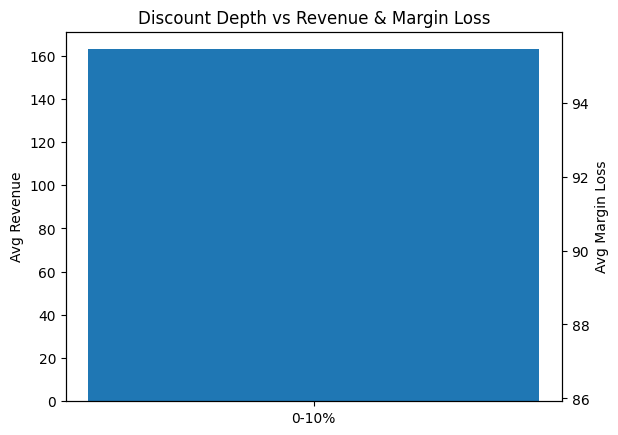

In [367]:
#2.4 Visualization

fig, ax1 = plt.subplots()

ax1.bar(discount_analysis['Discount_Bucket'], discount_analysis['Revenue'])
ax1.set_ylabel("Avg Revenue")

ax2 = ax1.twinx()
ax2.plot(discount_analysis['Discount_Bucket'], discount_analysis['Margin_Loss'], marker='o')
ax2.set_ylabel("Avg Margin Loss")

plt.title("Discount Depth vs Revenue & Margin Loss")
plt.show()

# OBJECTIVE 3.Evaluation of Promotion Effectiveness by Product Category

In [368]:
category_effectiveness = df.groupby('Category').agg({
    'Revenue': 'mean',
    'corrected_Depth%': 'mean',
    'Margin_Loss': 'mean'
}).sort_values(by='Revenue', ascending=False)

print(category_effectiveness)



#Efficiency Score

df['Efficiency'] = df['Revenue'] / (df['Margin_Loss'] + 1)

efficiency_by_category = df.groupby('Category')['Efficiency'].mean().sort_values(ascending=False)

print(efficiency_by_category)

                            Revenue  corrected_Depth%  Margin_Loss
Category                                                          
MOBILITY AIDS            514.670000          0.169999   118.000000
MEN HEALTH               428.574038          0.849038   208.852564
FRAGRANCES               346.191789          0.444677   230.677419
DERMO SKIN CARE          326.902552          0.882603   185.983345
HAIR TREATMENT           304.768305          0.857126   166.594595
WOMEN HEALTH             299.847856          0.839954   171.503386
HEALTHY NUTRITION        291.134967          0.758170   142.496732
GENERAL HEALTH           235.719578          0.839347   121.585413
ELECTRICAL HAIR TOOLS    208.746154          0.240379    92.115385
MEDICAL DEVICES          187.478866          0.240718    58.494845
PROFESSIONAL HAIR CARE   182.914737          0.570000    72.005263
KIDS HEALTH              179.967054          0.855814    93.527132
BEAUTY SKIN CARE         173.523592          0.869190   101.58

In [369]:
df.groupby('LABELS').agg({'corrected_Depth%':'sum','Saving':'sum','Promo Price with VAT':'mean'})

,corrected_Depth%,Saving,Promo Price with VAT
LABELS,,,
OTHERS,14154.978487,1793127.0,183.627575
PL,2329.304547,111523.0,55.290190


In [370]:
df.groupby(['LABELS','OFFER TYPE'])['OFFER TYPE'].count()

LABELS  OFFER TYPE                     
OTHERS  (B/G) BUY 2 GET 1 FREE                5
        BUY 1 GET 1 FREE                   1912
        BUY 1 GET 1 WITH PERCENT OFF 30     555
        BUY 1 GET 1 WITH PERCENT OFF 40    1834
        BUY 1 GET 1 WITH PERCENT OFF 50    1579
        BUY 1 GET 1 WITH PERCENT OFF 60     160
        BUY 1 GET 2 FREE                     54
        BUY 2 GET 1 FREE                   4908
        BUY 2 GET 2 FREE                   2019
        Direct_Discount                    4551
PL      (B/G) BUY 2 GET 1 FREE               12
        BUY 1 GET 1 FREE                   1542
        BUY 1 GET 1 WITH PERCENT OFF 50     693
        BUY 1 GET 1 WITH PERCENT OFF 70      10
        BUY 2 GET 1 FREE                     16
        Direct_Discount                    1107
Name: OFFER TYPE, dtype: int64

# OBJECTIVE 4.Gain Made by Customers vs Loss to Company

In [371]:
#4.1 Customer Savings

total_customer_savings = df['Saving'].sum()

total_customer_savings 

np.float64(1904650.0)

In [372]:
total_customer__monthly_savings = df.groupby('Promo_Month')['Saving'].sum()
total_customer__monthly_savings



Promo_Month
2    869627.0
3    475654.0
4    559369.0
Name: Saving, dtype: float64

In [373]:
#4.2 Company Revenue Sacrifice
total_revenue_sacrifice = (df['Price with VAT'] - df['Promo Price with VAT']).sum()
total_revenue_sacrifice 

np.float64(1916947.5899999999)

In [374]:
#4.3 Net Value Transfer
value_transfer = pd.DataFrame({
    'Metric': ['Customer Gain', 'Company Loss'],
    'Value': [total_customer_savings, total_revenue_sacrifice]
})

print(value_transfer)

          Metric       Value
0  Customer Gain  1904650.00
1   Company Loss  1916947.59


In [375]:
#4.4 Who Benefits More?

if total_customer_savings > total_revenue_sacrifice:
    print("Customers benefit more")
else:
    print("Company retains more value")

Company retains more value


# OBJECTIVE 5.Incrementality Assessment 

In [376]:
#5.1 Proxy: Promotion Frequency
promo_frequency = df.groupby('ITEM')['Promo_Month'].nunique()
df['High_Frequency_Promo'] = df['ITEM'].map(promo_frequency) > 2

In [377]:
#5.2 Flag Cannibalization Risk

df['Cannibalization_Risk'] = np.where(
    (df['High_Frequency_Promo']) & (df['corrected_Depth%'] > 30),
    1, 0
)

In [378]:
#5.3 Time-Shifting Detection

df = df.sort_values(['ITEM', 'START_DATE'])

df['Prev_Promo_End'] = df.groupby('ITEM')['END_DATE'].shift(1)

df['Gap_Days'] = (df['START_DATE'] - df['Prev_Promo_End']).dt.days

df['Back_to_Back_Promo'] = df['Gap_Days'] < 7

In [379]:
#5.4 Flag Non-Incremental Promotions

df['Non_Incremental_Flag'] = np.where(
    (df['Back_to_Back_Promo']) & (df['corrected_Depth%'] > 25),
    1, 0
)

In [380]:
non_incremental_rate = df['Non_Incremental_Flag'].mean() * 100
print(f"Non-incremental promotions: {non_incremental_rate:.2f}%")

Non-incremental promotions: 0.00%


In [381]:
kpis = {
    "Avg Discount %": df['corrected_Depth%'].mean(),
    "Total Customer Savings": df['Saving'].sum(),
    "Avg Promo Price": df['Promo Price with VAT'].mean(),
    "High Discount Ratio": (df['corrected_Depth%'] > 40).mean(),
    "Non Incremental Promo %": df['Non_Incremental_Flag'].mean()
}

for k, v in kpis.items():
    print(f"{k}: {v}")

Avg Discount %: 0.7865764676926286
Total Customer Savings: 1904650.0
Avg Promo Price: 162.95685029597098
High Discount Ratio: 0.0
Non Incremental Promo %: 0.0


            Promo_Count
Date                   
2026-02-01         7839
2026-02-08            0
2026-02-15            0
2026-02-22            0
2026-03-01         6325


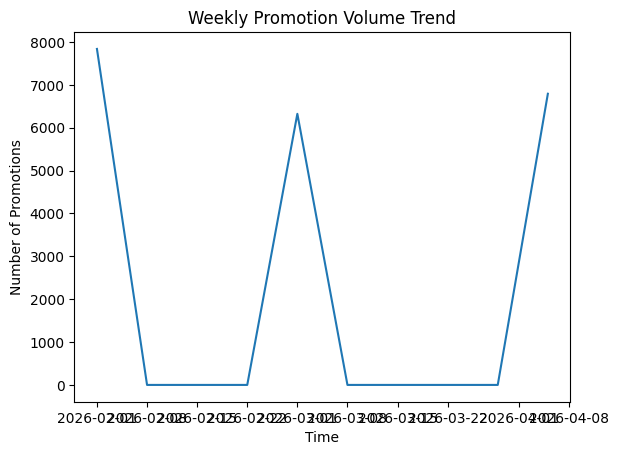

In [382]:
#Promotion Volume Over Time
df['Date'] = df['START_DATE']
df = df.sort_values('Date')
df.set_index('Date', inplace=True)

promo_trend = df.resample('W').agg({
    'ITEM': 'count'
}).rename(columns={'ITEM': 'Promo_Count'})

print(promo_trend.head())

plt.figure()
plt.plot(promo_trend.index, promo_trend['Promo_Count'])
plt.title("Weekly Promotion Volume Trend")
plt.xlabel("Time")
plt.ylabel("Number of Promotions")
plt.show()

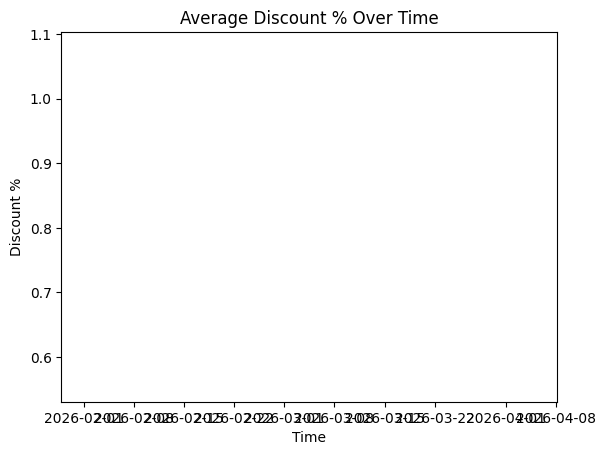

In [383]:
#Discount Depth Trend (Margin Pressure)
discount_trend = df.resample('W').agg({
    'corrected_Depth%': 'mean',
    'Margin_Loss': 'mean'
})
plt.figure()
plt.plot(discount_trend.index, discount_trend['corrected_Depth%'])
plt.title("Average Discount % Over Time")
plt.xlabel("Time")
plt.ylabel("Discount %")
plt.show()

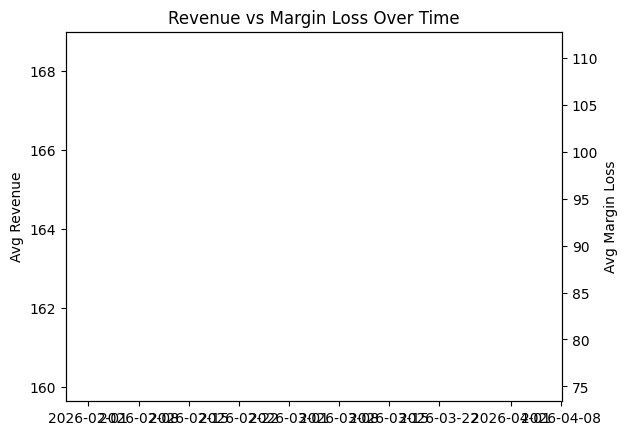

In [384]:
#Revenue vs Margin Trade-Off Over Time
time_value = df.resample('W').agg({
    'Revenue': 'mean',
    'Margin_Loss': 'mean'
})

fig, ax1 = plt.subplots()

ax1.plot(time_value.index, time_value['Revenue'])
ax1.set_ylabel("Avg Revenue")

ax2 = ax1.twinx()
ax2.plot(time_value.index, time_value['Margin_Loss'])
ax2.set_ylabel("Avg Margin Loss")

plt.title("Revenue vs Margin Loss Over Time")
plt.show()

       corrected_Depth%     Revenue  Margin_Loss
Month                                           
2              1.076818  160.071658   111.020937
3              0.556846  160.515281    75.202213
4              0.665545  168.559595    82.381296


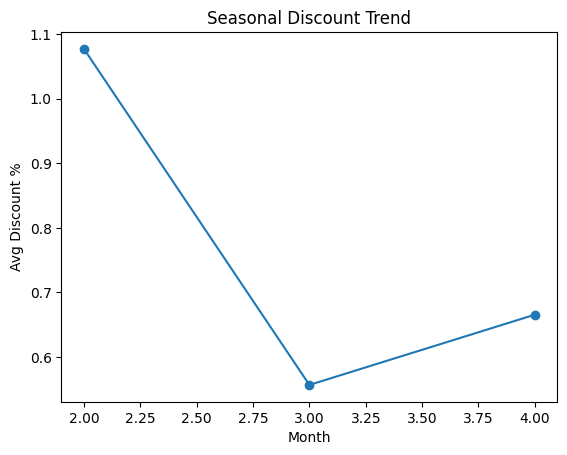

In [385]:
#Monthly Seasonality Analysis

df['Month'] = df.index.month

seasonality = df.groupby('Month').agg({
    'corrected_Depth%': 'mean',
    'Revenue': 'mean',
    'Margin_Loss': 'mean'
})

print(seasonality)

plt.figure()
plt.plot(seasonality.index, seasonality['corrected_Depth%'], marker='o')
plt.title("Seasonal Discount Trend")
plt.xlabel("Month")
plt.ylabel("Avg Discount %")
plt.show()

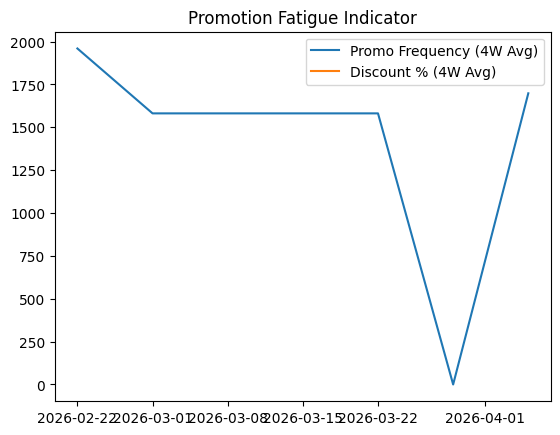

In [386]:
#Promotion Fatigue Detection that is If promotions happen too frequently → customers wait for discounts

rolling_promo = df['ITEM'].resample('W').count().rolling(4).mean()

rolling_promo = df['ITEM'].resample('W').count().rolling(4).mean()

rolling_discount = df['corrected_Depth%'].resample('W').mean().rolling(4).mean()

plt.figure()
plt.plot(rolling_promo.index, rolling_promo, label='Promo Frequency (4W Avg)')
plt.plot(rolling_discount.index, rolling_discount, label='Discount % (4W Avg)')
plt.legend()
plt.title("Promotion Fatigue Indicator")
plt.show()

In [387]:
#Detect Risk Periods Automatically

risk_periods = time_value[
    (time_value['Margin_Loss'] > time_value['Margin_Loss'].quantile(0.75)) &
    (time_value['Revenue'] < time_value['Revenue'].median())
]

print(risk_periods)

               Revenue  Margin_Loss
Date                               
2026-02-01  160.071658   111.020937


In [388]:
time_kpis = {
    "Peak Promo Week": promo_trend['Promo_Count'].idxmax(),
    "Highest Discount Period": discount_trend['corrected_Depth%'].idxmax(),
    "Worst Margin Week": time_value['Margin_Loss'].idxmax()
}

for k, v in time_kpis.items():
    print(f"{k}: {v}")

Peak Promo Week: 2026-02-01 00:00:00
Highest Discount Period: 2026-02-01 00:00:00
Worst Margin Week: 2026-02-01 00:00:00


RECOMMENDATIONS:


1. Shift from Volume-Driven to Profit-Driven Promotions
Introduce margin guardrails for all campaigns
Avoid deep discounting without clear ROI justification
2. Optimize Discount Depth
Identify and enforce optimal discount bands per category
Reduce unnecessary over-discounting
3. Prioritize High-Margin Categories
Focus promotions on products that:
Can absorb discounts
Drive profitable basket expansion
4. Implement Promotion Performance Dashboard
Track in real-time:
Revenue vs margin impact
Discount efficiency
Category performance
5. Move Toward Data-Driven Personalization (Future Scope)
Transition from blanket promotions to:
Targeted offers

Customer segmentation strategies (e.g., RFM)

Business Impact

This analysis enables leadership to:

Eliminate hidden financial leakage

Improve promotion ROI

Balance growth and profitability

Build a sustainable promotional strategy

In [389]:
import pandas as pd
import numpy as np
from dash import Dash, dcc, html, Input, Output
import plotly.express as px

import streamlit as st

# =========================
# LOAD & PREP DATA
# =========================


df['START_DATE'] = pd.to_datetime(df['START_DATE'])
df['Date'] = df['START_DATE']

# Discount engineering
df['Calculated_Discount_%'] = (
    (df['Price with VAT'] - df['Promo Price with VAT']) 
    / df['Price with VAT']
) * 100

df['Final_Discount_%'] = df['corrected_Depth%'].fillna(df['Depth%'])
df['Final_Discount_%'] = df['Final_Discount_%'].fillna(df['Calculated_Discount_%'])

# Core metrics
df['Revenue'] = df['Promo Price with VAT']
df['Margin_Loss'] = df['Saving']
df['Month'] = df['Date'].dt.month

# =========================
# INIT APP
# =========================
app = Dash(__name__)

# =========================
# LAYOUT
# =========================
app.layout = html.Div([
    
    html.H1(" Promotion Performance Dashboard", style={'textAlign': 'center'}),

    # FILTERS
    html.Div([
        dcc.Dropdown(
            id='category_filter',
            options=[{'label': i, 'value': i} for i in df['Category'].dropna().unique()],
            multi=True,
            placeholder="Select Category"
        ),

        dcc.Dropdown(
            id='channel_filter',
            options=[{'label': i, 'value': i} for i in df['Channel'].dropna().unique()],
            multi=True,
            placeholder="Select Channel"
        )
    ], style={'display': 'flex', 'gap': '20px'}),

    # KPIs
    html.Div(id='kpi_cards', style={'display': 'flex', 'justifyContent': 'space-around'}),

    # CHARTS
    dcc.Graph(id='promo_trend'),
    dcc.Graph(id='discount_vs_margin'),
    dcc.Graph(id='category_performance')

])

# =========================
# CALLBACK
# =========================
@app.callback(
    [Output('kpi_cards', 'children'),
     Output('promo_trend', 'figure'),
     Output('discount_vs_margin', 'figure'),
     Output('category_performance', 'figure')],
    
    [Input('category_filter', 'value'),
     Input('channel_filter', 'value')]
)
def update_dashboard(category, channel):

    dff = df.copy()

    if category:
        dff = dff[dff['Category'].isin(category)]

    if channel:
        dff = dff[dff['Channel'].isin(channel)]

    # =========================
    # KPIs
    # =========================
    avg_discount = round(dff['Final_Discount_%'].mean(), 2)
    total_savings = round(dff['Saving'].sum(), 2)
    total_revenue = round(dff['Revenue'].sum(), 2)
    high_discount_ratio = round((dff['Final_Discount_%'] > 40).mean() * 100, 2)

    kpis = [
        html.Div(f"Avg Discount: {avg_discount}%"),
        html.Div(f"Customer Savings: {total_savings}"),
        html.Div(f"Revenue: {total_revenue}"),
        html.Div(f"High Discount %: {high_discount_ratio}%")
    ]

    # =========================
    # TIME SERIES
    # =========================
    trend = dff.resample('W', on='Date').agg({
        'ITEM': 'count'
    }).rename(columns={'ITEM': 'Promotions'})

    fig_trend = px.line(trend, x=trend.index, y='Promotions',
                        title="Weekly Promotion Trend")

    # =========================
    # DISCOUNT VS MARGIN
    # =========================
    fig_scatter = px.scatter(
        dff,
        x='Final_Discount_%',
        y='Margin_Loss',
        color='Category',
        title="Discount vs Margin Loss"
    )

    # =========================
    # CATEGORY PERFORMANCE
    # =========================
    cat_perf = dff.groupby('Category').agg({
        'Revenue': 'mean',
        'Margin_Loss': 'mean'
    }).reset_index()

    fig_cat = px.bar(cat_perf, x='Category', y='Revenue',
                     title="Category Revenue Performance")

    return kpis, fig_trend, fig_scatter, fig_cat

# =========================
# RUN APP
# =========================
if __name__ == "__main__":
    app.run(debug=True)